In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据集根目录
data_root = '../data/raw/ATC/'

def load_all_trajectories(data_root):
    """
    加载ATC数据集中所有行人轨迹
    
    参数:
        data_root: 数据集根目录，包含ATC-1到ATC-6文件夹
    
    返回:
        trajectories: 列表，每个元素是一条轨迹的二维数组 (n_points, 2)
        metadata: 列表，每个元素包含轨迹的元信息（天数、行人ID等）
    """
    all_trajectories = []
    all_metadata = []
    
    # 遍历6天的数据
    for day_idx in range(1, 7):
        day_folder = f'ATC-{day_idx}'
        day_path = os.path.join(data_root, day_folder)
        
        if not os.path.exists(day_path):
            print(f'跳过 {day_folder}，目录不存在')
            continue
            
        # 遍历目录下的所有csv文件
        for filename in os.listdir(day_path):
            if not filename.endswith('.csv'):
                continue
                
            file_path = os.path.join(day_path, filename)
            
            # 读取CSV文件（ATC数据集通常没有表头）
            # 列格式一般为: frame_id, person_id, x, y, ...
            df = pd.read_csv(file_path, header=None)
            
            # 根据ATC数据集的标准格式，前4列通常是: frame, id, x, y
            if df.shape[1] >= 4:
                df.columns = ['frame', 'id', 'x', 'y'] + [f'col_{i}' for i in range(4, df.shape[1])]
            else:
                print(f'文件 {filename} 列数不足，跳过')
                continue
            
            # 按行人ID分组
            for person_id, group in df.groupby('id'):
                # 按帧号排序
                group = group.sort_values('frame')
                
                # 提取坐标序列
                trajectory = group[['x', 'y']].values
                
                # 只保留长度大于10的轨迹（太短的没有分析价值）
                if len(trajectory) >= 10:
                    all_trajectories.append(trajectory)
                    all_metadata.append({
                        'day': day_idx,
                        'person_id': person_id,
                        'length': len(trajectory),
                        'file': filename
                    })
    
    return all_trajectories, all_metadata

# 加载所有数据
trajectories, metadata = load_all_trajectories(data_root)

print(f'成功加载 {len(trajectories)} 条有效轨迹')
print(f'数据来自 {len(set(m["day"] for m in metadata))} 天')

成功加载 88129 条有效轨迹
数据来自 6 天


=== 轨迹长度统计 ===
总轨迹数: 88129
最短轨迹: 10 个点
最长轨迹: 112198 个点
平均长度: 928.0 个点
中位数长度: 542 个点


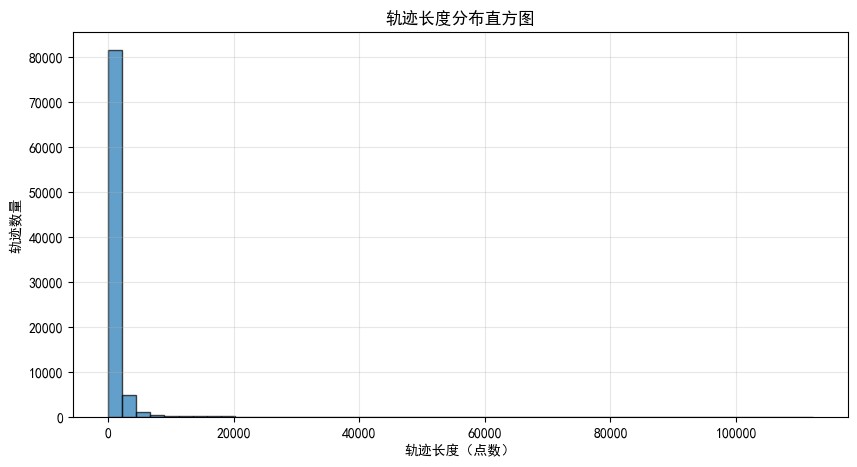


=== 每日轨迹数量 ===
第 1 天: 7249 条轨迹
第 2 天: 18964 条轨迹
第 3 天: 18130 条轨迹
第 4 天: 5640 条轨迹
第 5 天: 31375 条轨迹
第 6 天: 6771 条轨迹


In [2]:
# 计算轨迹长度统计
lengths = [len(traj) for traj in trajectories]

print('=== 轨迹长度统计 ===')
print(f'总轨迹数: {len(trajectories)}')
print(f'最短轨迹: {min(lengths)} 个点')
print(f'最长轨迹: {max(lengths)} 个点')
print(f'平均长度: {np.mean(lengths):.1f} 个点')
print(f'中位数长度: {np.median(lengths):.0f} 个点')

# 绘制轨迹长度分布直方图
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('轨迹长度（点数）')
plt.ylabel('轨迹数量')
plt.title('轨迹长度分布直方图')
plt.grid(True, alpha=0.3)
plt.show()

# 统计每天的轨迹数量
day_counts = {}
for m in metadata:
    day = m['day']
    day_counts[day] = day_counts.get(day, 0) + 1

print('\n=== 每日轨迹数量 ===')
for day in sorted(day_counts.keys()):
    print(f'第 {day} 天: {day_counts[day]} 条轨迹')

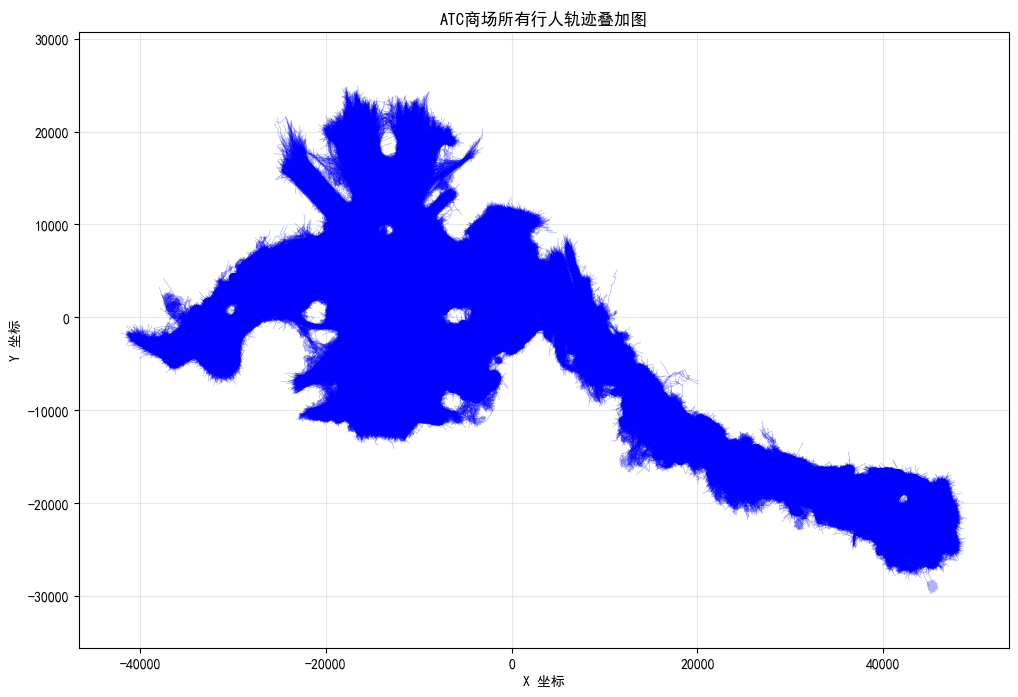

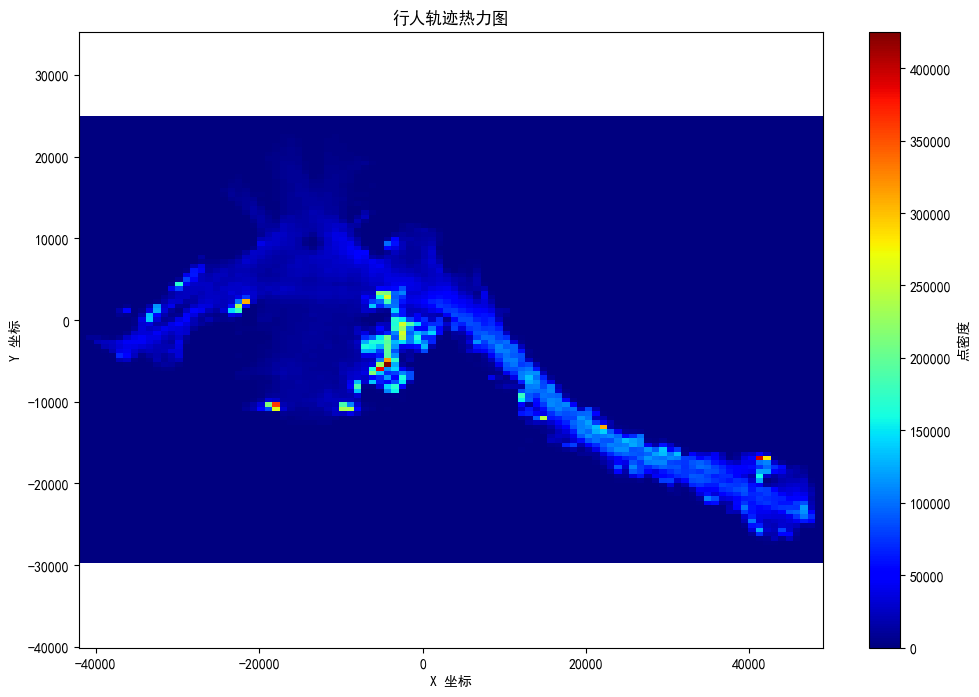

In [3]:
plt.figure(figsize=(12, 8))

# 绘制所有轨迹
for traj in trajectories:
    plt.plot(traj[:, 0], traj[:, 1], linewidth=0.5, alpha=0.3, color='blue')

plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.title('ATC商场所有行人轨迹叠加图')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # 保持坐标轴比例一致
plt.show()

# 绘制轨迹密度热力图
all_x = np.concatenate([traj[:, 0] for traj in trajectories])
all_y = np.concatenate([traj[:, 1] for traj in trajectories])

plt.figure(figsize=(12, 8))
plt.hist2d(all_x, all_y, bins=100, cmap='jet')
plt.colorbar(label='点密度')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.title('行人轨迹热力图')
plt.axis('equal')
plt.show()

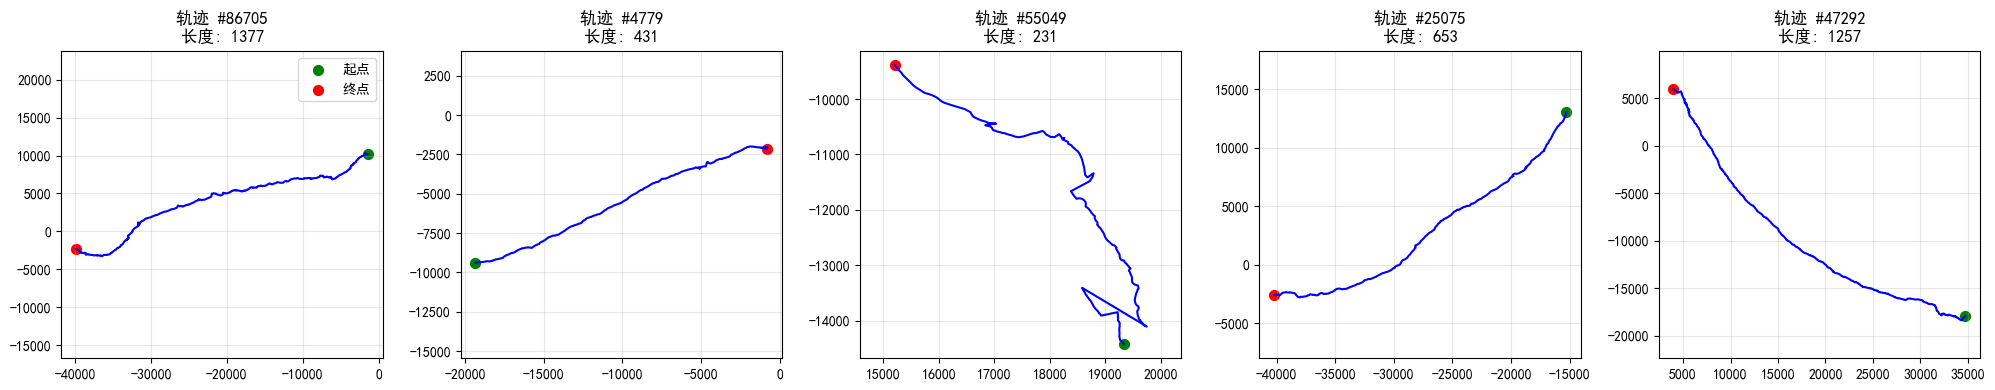

In [4]:
# 随机抽取5条轨迹进行可视化
np.random.seed(42)
sample_indices = np.random.choice(len(trajectories), 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, idx in enumerate(sample_indices):
    traj = trajectories[idx]
    axes[i].plot(traj[:, 0], traj[:, 1], 'b-', linewidth=1.5)
    axes[i].scatter(traj[0, 0], traj[0, 1], c='green', s=50, label='起点')
    axes[i].scatter(traj[-1, 0], traj[-1, 1], c='red', s=50, label='终点')
    axes[i].set_title(f'轨迹 #{idx}\n长度: {len(traj)}')
    axes[i].axis('equal')
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.show()